In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('matches.csv')
print(df.shape)
df.head()

(1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
print(df.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [4]:
df = df.dropna(subset=['winner'])
print(df.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64


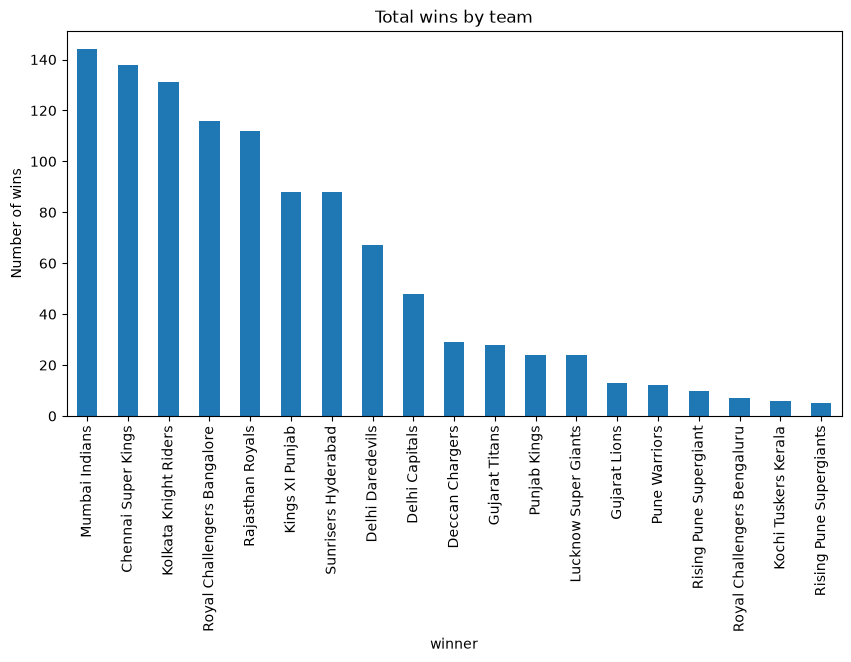

In [5]:
df['winner'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Total wins by team')
plt.ylabel('Number of wins')
plt.show()

True     0.508257
False    0.491743
Name: proportion, dtype: float64


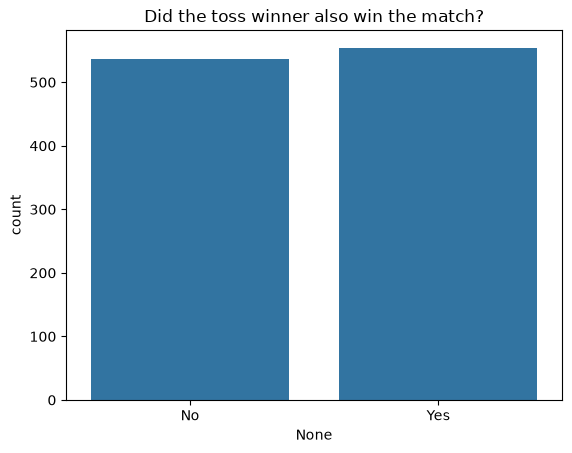

In [6]:
toss_match = (df['toss_winner'] == df['winner']).value_counts(normalize=True)
print(toss_match)
sns.countplot(x=(df['toss_winner'] == df['winner']))
plt.title('Did the toss winner also win the match?')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

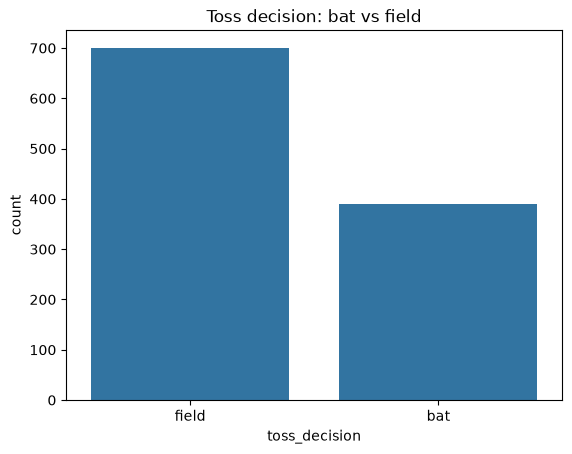

In [7]:
sns.countplot(x='toss_decision', data=df)
plt.title('Toss decision: bat vs field')
plt.show()

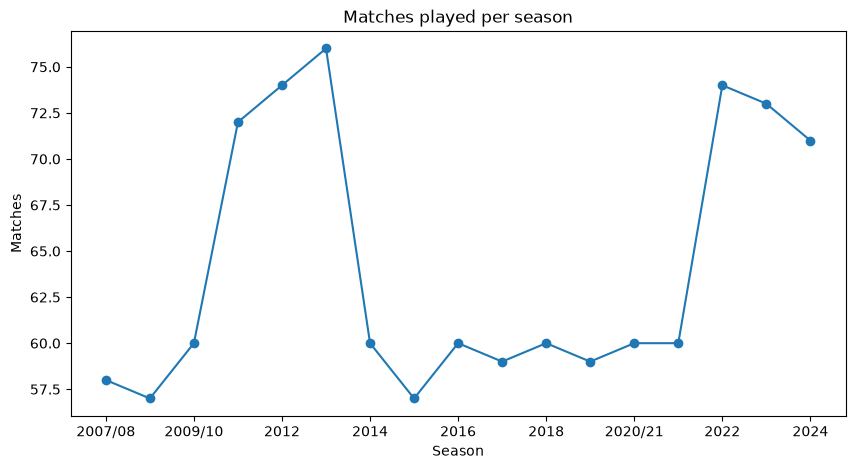

In [8]:
df['season'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(10,5))
plt.title('Matches played per season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.show()

Toss winners win the match only 50.8 percent of the time, almost exactly a coin flip - winning the toss is not a major advantage in IPL matches.

Toss winners win the match only 50.8 percent of the time, almost exactly a coin flip - winning the toss is not a major advantage in IPL matches.


In [11]:
from sklearn.preprocessing import LabelEncoder

model_df = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']].dropna()

le = LabelEncoder()
encoders = {}
for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = model_df.drop('winner', axis=1)
y = model_df['winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.47706422018348627


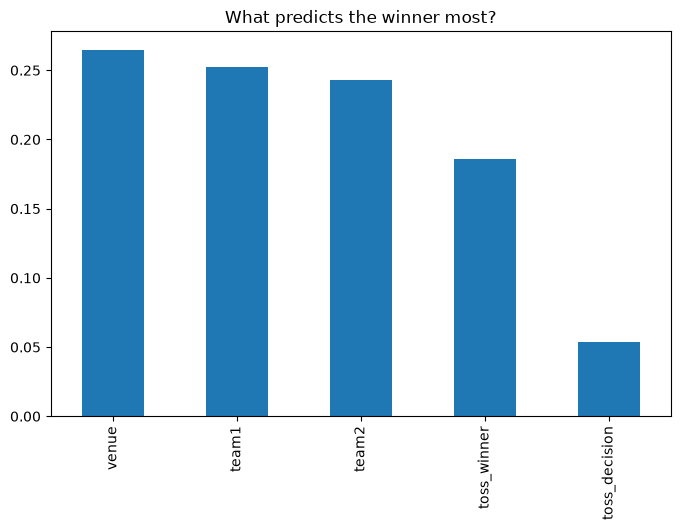

In [14]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', figsize=(8,5))
plt.title('What predicts the winner most?')
plt.show()

Conclusion: The Random Forest model achieved 47.7% accuracy predicting the match winner. Venue was the strongest predictor, even more than which teams were playing, suggesting that ground conditions and home advantage play a major role in IPL outcomes. Toss decision had almost no predictive value, consistent with the earlier finding that toss winners only win matches 50.8% of the time. A limitation of this model is that it does not account for current player form, injuries, or recent team changes, which likely influence real outcomes more than these historical features.